# Fraud Detection EDA and Modelling

This notebook explores transaction data, trains a fraud model, and explains how the project supports a CV/GitHub portfolio.

In [4]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)
print("Python:", sys.executable)

Project root: c:\Users\aliye\OneDrive\Desktop\fraud-xai-streamlit\fraud-xai-streamlit
Python: c:\Users\aliye\OneDrive\Desktop\fraud-xai-streamlit\fraud-xai-streamlit\.venv\Scripts\python.exe


In [5]:
from src.features import FEATURE_COLUMNS
from src.data_generator import generate_transactions

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from src.data_generator import generate_transactions
from src.train import train

## 1. Generate or Load Data

In [7]:
data_path = Path('../data/raw/transactions.csv')
data_path.parent.mkdir(parents=True, exist_ok=True)

if not data_path.exists():
    df = generate_transactions(rows=50000, seed=42)
    df.to_csv(data_path, index=False)
else:
    df = pd.read_csv(data_path)

df.head()

,transaction_id,amount,hour,day_of_week,merchant_risk_score,customer_age,account_age_days,previous_failed_attempts,num_transactions_24h,foreign_transaction,card_present,device_trust_score,is_weekend,night_transaction,is_fraud
0,TXN0000000,33.27,6,5,0.2271,39,928,1,5,0,1,0.8228,1,0,0
1,TXN0000001,8.67,8,3,0.3177,75,76,0,3,0,1,0.9387,0,0,0
2,TXN0000002,51.96,12,1,0.0104,57,1282,0,6,1,1,0.7080,0,0,0
3,TXN0000003,62.84,17,0,0.1127,78,315,0,0,0,1,0.7575,0,0,0
4,TXN0000004,3.49,20,0,0.2117,44,641,0,1,0,1,0.8022,0,0,0


In [8]:
df.shape, df['is_fraud'].mean()

((50000, 15), np.float64(0.01242))

## 2. Exploratory Analysis

In [9]:
df['is_fraud'].value_counts(normalize=True).rename('share')

is_fraud
0    0.98758
1    0.01242
Name: share, dtype: float64

In [10]:
df.groupby('is_fraud')[[
    'amount', 'merchant_risk_score', 'device_trust_score',
    'previous_failed_attempts', 'num_transactions_24h'
]].mean()

,amount,merchant_risk_score,device_trust_score,previous_failed_attempts,num_transactions_24h
is_fraud,,,,,
0,40.064785,0.284675,0.714811,0.296341,2.195994
1,82.249758,0.313805,0.689606,0.428341,2.400966


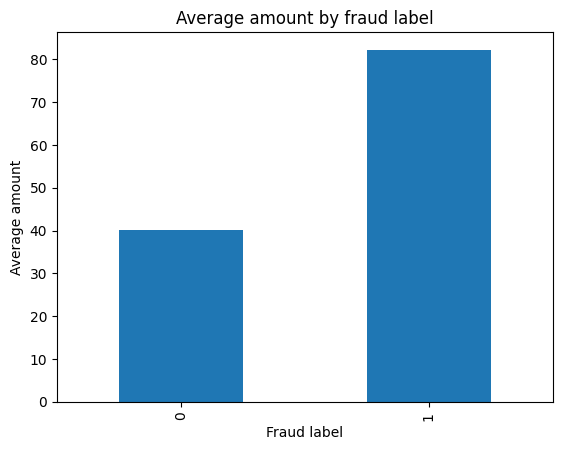

In [11]:
ax = df.groupby('is_fraud')['amount'].mean().plot(kind='bar', title='Average amount by fraud label')
ax.set_xlabel('Fraud label')
ax.set_ylabel('Average amount')
plt.show()

## 3. Train Model

In [12]:
metrics = train(str(data_path), model_dir='../models', threshold=0.35)
metrics

{'threshold': 0.35,
 'accuracy': 0.64256,
 'precision': 0.0230037602300376,
 'recall': 0.6709677419354839,
 'f1': 0.04448246364414029,
 'roc_auc': 0.7173545512745136,
 'pr_auc': 0.03052454242018593,
 'true_negatives': 7928,
 'false_positives': 4417,
 'false_negatives': 51,
 'true_positives': 104,
 'training_seconds': 0.7897255001589656,
 'latency_ms_per_1000_transactions': 1.1007199995219707,
 'test_rows': 12500,
 'fraud_rate': 0.01242}

## 4. Interpretation

The Streamlit dashboard provides local SHAP explanations for individual fraud predictions. For GitHub, include screenshots of metrics, the prediction form, and the SHAP contribution chart.